# LLM-assisted analysis of real climate data


## Learning objectives

By the end, you can:

- write a pseudocode task/effective prompt for an AI tool
- identify which facts about a data file an assistant cannot infer and must be told;
- compare downloading by hand against fetching programmatically;
- start developing your own workflows for loading and working with data

---

# Part 1 — The Keeling curve


### Setup - Importing packages and pointing to where our data will live. Run this cell once.

In [22]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CO2_RAW = Path("../data/raw/co2")
PIER_RAW = Path("../data/raw/pier")
CO2_RAW.mkdir(parents=True, exist_ok=True)
PIER_RAW.mkdir(parents=True, exist_ok=True)

## Activity 1 — Keeling curve from a local file

### 1.1 Download the file

1. Open the [Scripps CO2 Program primary Mauna Loa record](https://scrippsco2.ucsd.edu/data/primary-mauna-loa-co2-record/).
2. Download the **monthly in situ CO2** CSV.
3. Open the file to see the contents for yourself.
4. Leave it in Downloads for now

### 1.2 Add the file to the context window of an AI tool

This CSV is small enough to attach to a chat directly. Start a new chat in your AI tool of choice (Gemini, Claude, Chat GPT etc), attach the file (drag and drop it from Finder), and ask for a description *before* any code:

```text
This is a CSV of atmospheric CO2 levels. Before writing any code, describe
its structure. Do not write plotting code yet.
```

Verify what it told you against what you see in the file itself. 

### 1.3 Generate a script to plot the data

Now that you've gotten the data structure into the context window, you can generate a script to make plots. Some AI tools can run code and render plots in the chat window itself.

```text
Write me python code to plot this data in a Jupyter notebook from a local, user-defined path. Render the resulting plot in the chat as well. 
```
You will need to either move the csv into the data/ folder in your current project, or just point the code to your Downloads folder (this is ther user-defined path).

### Claude Opus 5:

The figure generated in the chat:

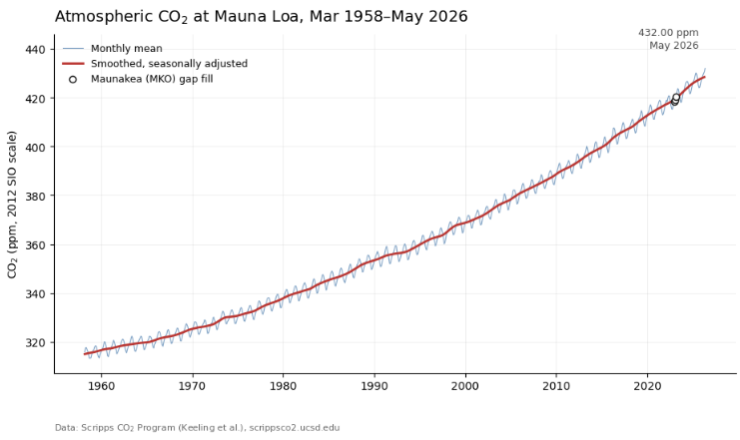

821 months, 1958-03 to 2026-05; 315.71 -> 432.00 ppm


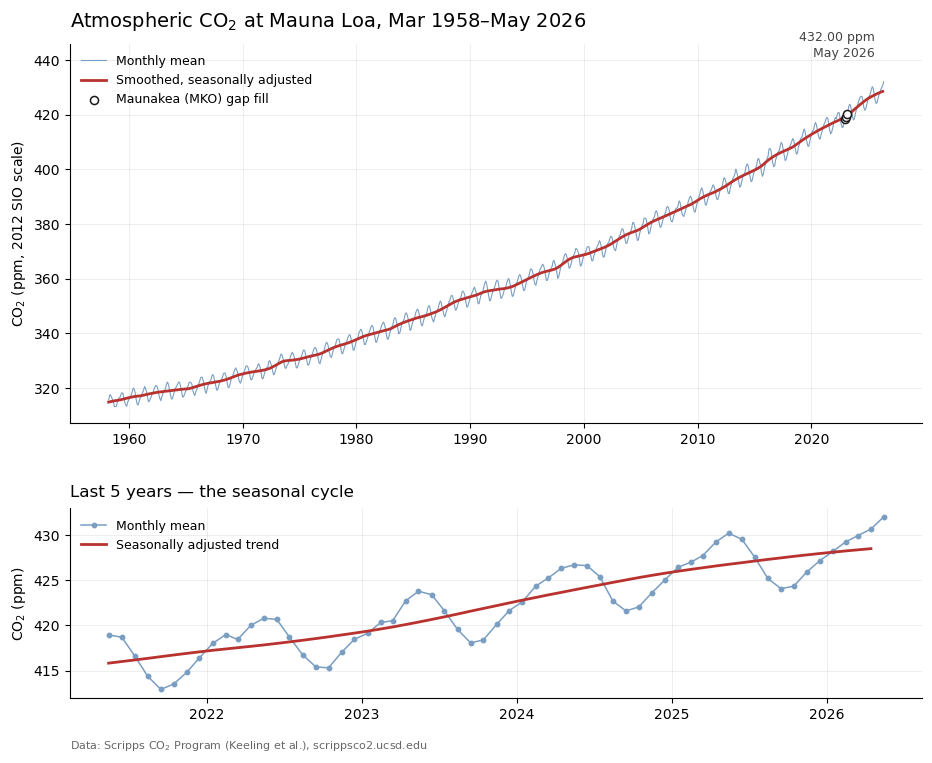

In [23]:
from pathlib import Path
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

CSV_PATH = Path("../data/raw/co2/monthly_in_situ_co2_mlo.csv")  # <-- edit me
RECENT_YEARS = 5

# 64 lines of quoted prose preamble; 11 columns (the file's docs say 10);
# -99.99 is the missing-value sentinel; fields are space-padded.
df = pd.read_csv(
    CSV_PATH, skiprows=64, na_values=[-99.99], skipinitialspace=True,
    names=["year", "month", "excel_date", "decimal_year", "co2", "co2_seas_adj",
           "co2_fit", "co2_fit_seas_adj", "co2_filled", "co2_seas_adj_filled",
           "station"],
)
df["date"] = pd.to_datetime(dict(year=df.year, month=df.month, day=15),
                            errors="coerce")
df = df.dropna(subset=["date"]).set_index("date")
df = df.loc[:df["co2"].last_valid_index()]  # drop the all-sentinel padding rows

obs = df["co2"].dropna()
last = obs.index[-1]
print(f"{len(df)} months, {obs.index[0]:%Y-%m} to {last:%Y-%m}; "
      f"{obs.iloc[0]:.2f} -> {obs.iloc[-1]:.2f} ppm")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8.5), height_ratios=[2, 1],
                               gridspec_kw={"hspace": 0.3})

ax1.plot(obs.index, obs.values, lw=0.8, color="#7a9ec2", label="Monthly mean")
ax1.plot(df.index, df["co2_fit_seas_adj"], lw=2, color="#b8322f",
         label="Smoothed, seasonally adjusted")
mko = df[df["station"] == "MKO"]  # Dec 2022-Feb 2023, measured from Maunakea
ax1.scatter(mko.index, mko["co2"], s=34, zorder=5, facecolor="white",
            edgecolor="#1a1a1a", lw=1.1, label="Maunakea (MKO) gap fill")
ax1.set_ylim(top=obs.max() + 14)
ax1.annotate(f"{obs.iloc[-1]:.2f} ppm\n{last:%b %Y}", xy=(last, obs.iloc[-1]),
             xytext=(-6, 16), textcoords="offset points", ha="right",
             va="bottom", fontsize=9, color="#444", linespacing=1.3)
ax1.set_title(f"Atmospheric CO$_2$ at Mauna Loa, {obs.index[0]:%b %Y}–{last:%b %Y}",
              fontsize=14, loc="left", pad=12)
ax1.set_ylabel("CO$_2$ (ppm, 2012 SIO scale)")

recent = df.loc[last - pd.DateOffset(years=RECENT_YEARS):]
ax2.plot(recent.index, recent["co2"], lw=1.1, marker="o", ms=3.2,
         color="#7a9ec2", label="Monthly mean")
ax2.plot(recent.index, recent["co2_fit_seas_adj"], lw=2, color="#b8322f",
         label="Seasonally adjusted trend")
ax2.set_title(f"Last {RECENT_YEARS} years — the seasonal cycle", fontsize=12,
              loc="left", pad=8)
ax2.set_ylabel("CO$_2$ (ppm)")
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

for ax in (ax1, ax2):
    ax.legend(frameon=False, loc="upper left", fontsize=9)
    ax.grid(alpha=0.25, lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)

fig.text(0.125, 0.05, "Data: Scripps CO$_2$ Program (Keeling et al.), "
         "scrippsco2.ucsd.edu", fontsize=8, color="#666")
plt.show()

### Gemini 3.1

No figure generated in the chat...

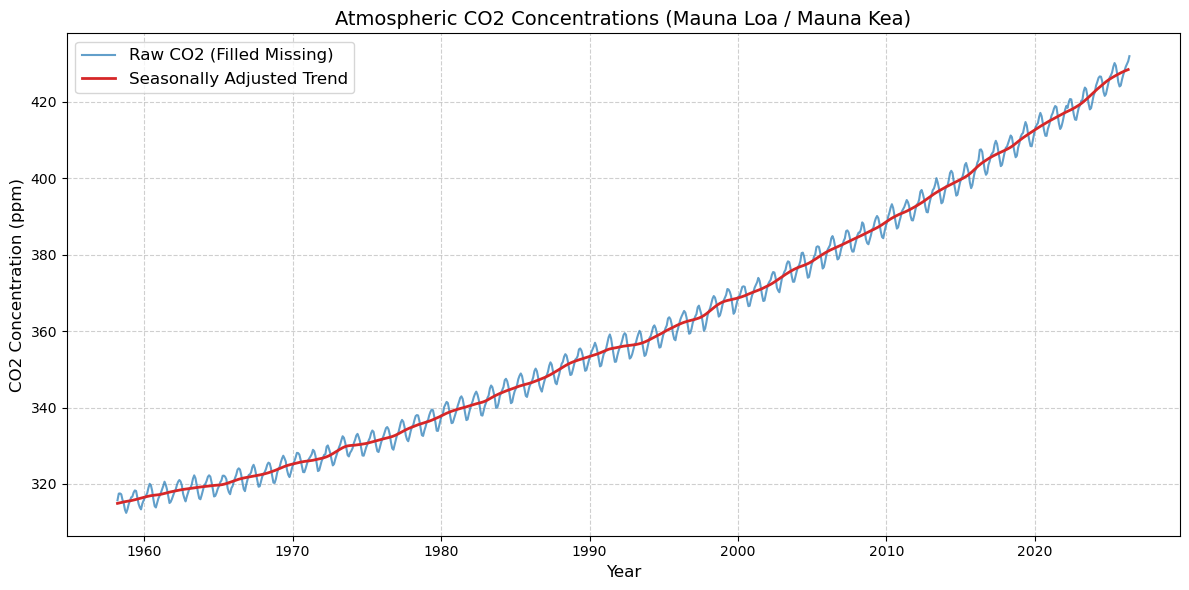

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Define your local path to the CSV file here
file_path = "../data/raw/co2/monthly_in_situ_co2_mlo.csv"

# Define column names to cleanly map the 11 columns
col_names = [
    'Yr', 'Mn', 'Date_Excel', 'Date', 'CO2', 'CO2_seasonally_adj', 
    'fit', 'seasonally_adjusted_fit', 'CO2_filled', 'seasonally_adjusted_filled', 'Sta'
]

# Read the CSV, skipping the 64 lines of metadata/headers 
# Missing values are encoded as -99.99 in the dataset
df = pd.read_csv(
    file_path, 
    skiprows=64, 
    names=col_names, 
    na_values="-99.99", 
    skipinitialspace=True
)

# Plotting the data inline for Jupyter Notebook
%matplotlib inline
plt.figure(figsize=(12, 6))

# Plot the raw CO2 concentrations (using the column where gaps have been filled)
plt.plot(df['Date'], df['CO2_filled'], label='Raw CO2 (Filled Missing)', color='#1f77b4', alpha=0.7)

# Plot the seasonally adjusted trend for clarity
plt.plot(df['Date'], df['seasonally_adjusted_fit'], label='Seasonally Adjusted Trend', color='#d62728', linewidth=2)

# Chart formatting
plt.title('Atmospheric CO2 Concentrations (Mauna Loa / Mauna Kea)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('CO2 Concentration (ppm)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Render the plot
plt.show()

### 1.4 Ask the AI to explain what it did

The code works, it's important that you know WHY and WHAT it is doing.

```text
Explain to me what each block of code is doing in this script.
```

Spend time walking through the output of this prompt to convince yourself that the code is doing what you expect it to be doing. This is also a good way to learn syntax. You can flag specific lines and ask for clarification. Understand where these two scripts are different and why they made different figures.

## Activity 2 — Repeat this process for the SIO Pier Temperature and Salinity data.


### 2.1 Download the file

1. Open the [Scripps Pier Shore Stations Page](https://library.ucsd.edu/dc/object/bb4003017c).
2. Download the zip file and unzip (double click it).
3. Open one of the files to see the contents for yourself.
4. Move it to data/ in your project folder so you can point to it later.

### 2.2 Add the file(s) to the context window of an AI tool

Depending on your AI tool, you may be able to add all of these files to the context window at once. Start a new chat in your AI tool of choice (Gemini, Claude, Chat GPT etc), attach the file (drag and drop it from Finder), and ask for a description *before* any code:

```text
These are CSVs of SIO pier data. Read and understand the contents and structure of these files.
```

Again, verify what it told you against what you see in the file itself. 

### 2.3 Generate a script to plot the data

Now that you've gotten the data structure into the context window, you can generate a script to make plots. Some AI tools can run code and render plots in the chat window itself.

```text
Write me python code i can paste into a Jupyter notebook to plot this data from a local, user-defined path. Make a two panel figure with Temperature on one and Salinity on the other.
```
You will need to either move the csv into the data/ folder in your current project, or just point the code to your Downloads folder (this is ther user-defined path).

### Claude Opus 5

In [15]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

# ------------------------------------------------------------------ config --
DATA_DIR  = Path("../data/raw/pier/bb4003017c_1_1").expanduser()   # <- your path here
TEMP_FILE = DATA_DIR / "LaJolla_TEMP_1916-202603.csv"
SALT_FILE = DATA_DIR / "LaJolla_SALT_1916-202603.csv"

HEADER_ROW  = 46            # lines of preamble before the column header
GOOD_ONLY   = True          # mask observations whose flag != 0
SHOW_DAILY  = True          # faint daily values behind the smoothed line
SMOOTH_DAYS = 365           # centered rolling-mean window
DATE_RANGE  = (None, None)  # e.g. ("1950-01-01", "2026-03-31")
OUTFILE     = None          # e.g. "scripps_pier_TS.png"

In [16]:
def load_shore_station(path, header_row=HEADER_ROW, good_only=GOOD_ONLY):
    """Read one Shore Stations file into a daily DatetimeIndex DataFrame.

    Strips the preamble and the trailing padding columns, builds the date
    index, and optionally masks flagged values. Flag columns are retained
    so you can inspect what was dropped.
    """
    df = pd.read_csv(path, skiprows=header_row)
    df = df.loc[:, ~df.columns.str.startswith("Unnamed")]

    df["date"] = pd.to_datetime(
        df[["YEAR", "MONTH", "DAY"]].rename(
            columns={"YEAR": "year", "MONTH": "month", "DAY": "day"})
    )
    df = df.set_index("date").drop(columns=["YEAR", "MONTH", "DAY"])

    if good_only:
        for level in ("SURF", "BOT"):
            value_col = next((c for c in df.columns
                              if c.startswith(level) and not c.endswith("FLAG")), None)
            flag_col = f"{level}_FLAG"
            if value_col and flag_col in df:
                # In the salinity file BOT_FLAG is 0 even where the value is
                # absent, so the NaNs in the value column do the real work.
                df[value_col] = df[value_col].where(df[flag_col] == 0)

    return df


temp = load_shore_station(TEMP_FILE)
salt = load_shore_station(SALT_FILE)

start, end = DATE_RANGE
temp, salt = temp.loc[start:end], salt.loc[start:end]

print(temp.shape, salt.shape)
temp.head()

(40034, 6) (40034, 6)


,TIME_PST,TIME_FLAG,SURF_TEMP_C,SURF_FLAG,BOT_TEMP_C,BOT_FLAG
date,,,,,,
1916-08-22,NaN,NaN,19.5,0,NaN,NaN
1916-08-23,NaN,NaN,19.9,0,NaN,NaN
1916-08-24,NaN,NaN,19.7,0,NaN,NaN
1916-08-25,NaN,NaN,19.7,0,NaN,NaN
1916-08-26,NaN,NaN,19.5,0,NaN,NaN


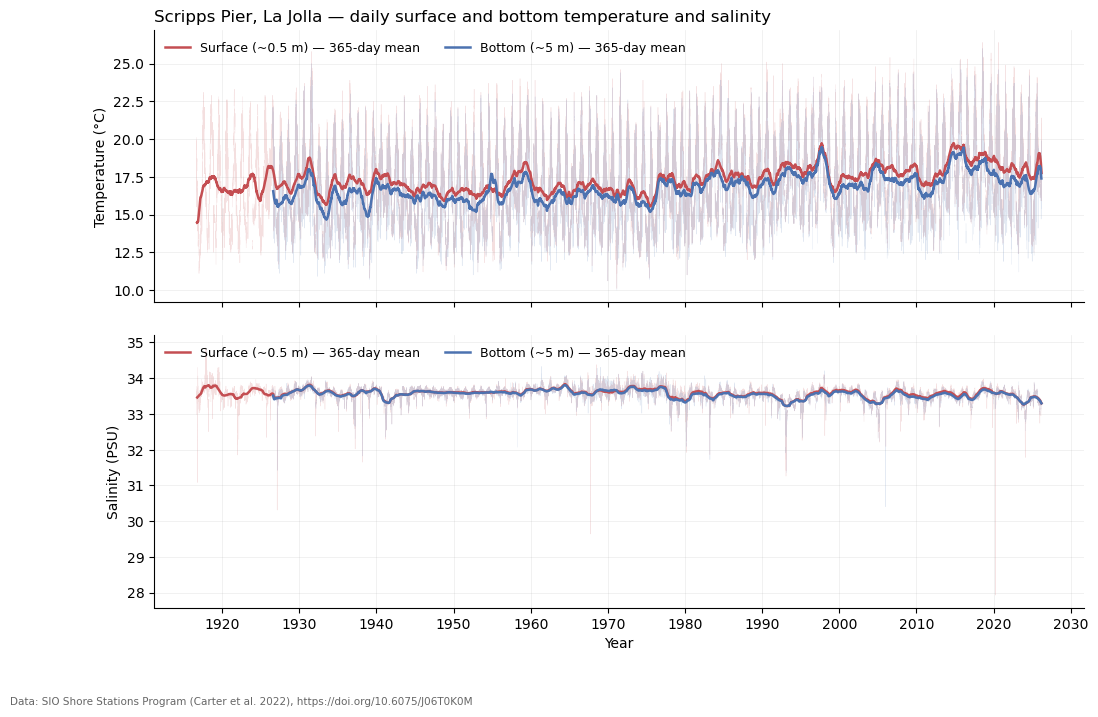

In [17]:
def smooth(series, window=SMOOTH_DAYS):
    """Centered rolling mean. The record has one row per calendar day with no
    gaps, so a fixed-width window is a true time window."""
    return series.rolling(window, center=True, min_periods=window // 2).mean()


PANELS = [
    dict(data=temp, ylabel="Temperature (°C)",
         series=[("SURF_TEMP_C", "Surface (~0.5 m)", "#c44e52"),
                 ("BOT_TEMP_C",  "Bottom (~5 m)",    "#4c72b0")]),
    dict(data=salt, ylabel="Salinity (PSU)",
         series=[("SURF_SAL_PSU", "Surface (~0.5 m)", "#c44e52"),
                 ("BOT_SAL_PSU",  "Bottom (~5 m)",    "#4c72b0")]),
]

fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True,
                         gridspec_kw=dict(hspace=0.12))

for ax, panel in zip(axes, PANELS):
    for col, label, color in panel["series"]:
        s = panel["data"][col]
        if SHOW_DAILY:
            ax.plot(s.index, s, color=color, lw=0.3, alpha=0.18, zorder=1)
        ax.plot(s.index, smooth(s), color=color, lw=1.8, zorder=3,
                label=f"{label} — {SMOOTH_DAYS}-day mean")
    ax.set_ylabel(panel["ylabel"])
    ax.grid(alpha=0.25, lw=0.5)
    ax.legend(loc="upper left", frameon=False, fontsize=9, ncol=2)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_title("Scripps Pier, La Jolla — daily surface and bottom "
                  "temperature and salinity", loc="left", fontsize=12)
axes[-1].set_xlabel("Year")
axes[-1].xaxis.set_major_locator(mdates.YearLocator(10))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.text(0.005, -0.02,
         "Data: SIO Shore Stations Program (Carter et al. 2022), "
         "https://doi.org/10.6075/J06T0K0M",
         fontsize=7.5, color="0.4")

if OUTFILE:
    fig.savefig(OUTFILE, dpi=200, bbox_inches="tight")
plt.show()

### Gemini 3.1

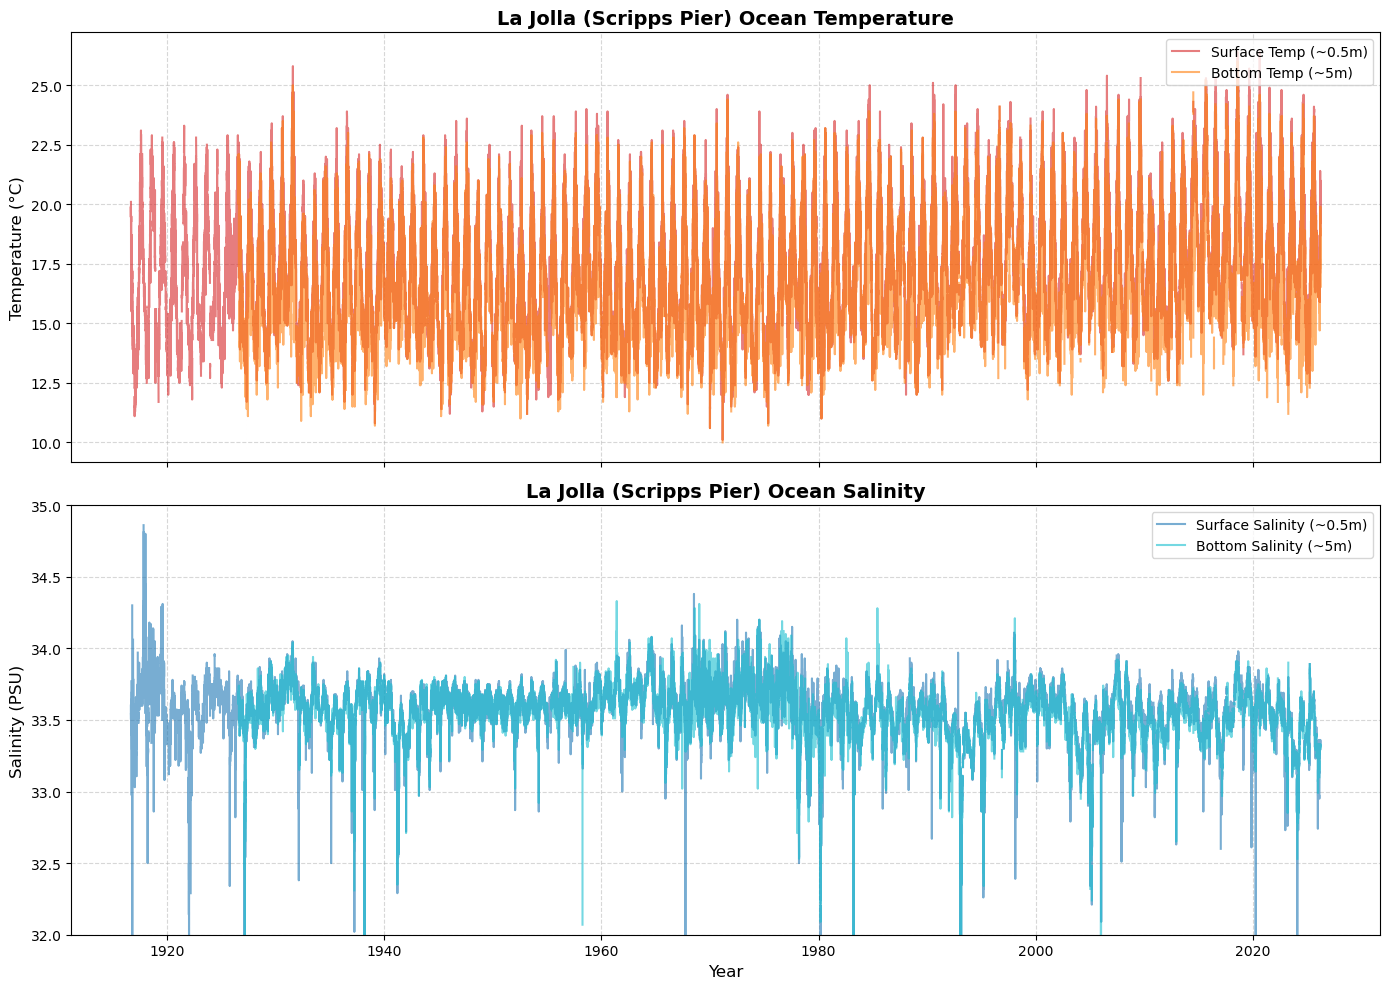

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. USER CONFIGURATION
# ==========================================
# Define the directory where your files are downloaded/stored.
# Note: Use raw strings (r"...") for Windows paths (e.g., r"C:\Users\Name\Downloads")
data_dir = r"../data/raw/pier/bb4003017c_1_1" 

# Define the file names (using the CSV versions by default)
temp_file = "LaJolla_TEMP_1916-202603.csv"
salt_file = "LaJolla_SALT_1916-202603.csv"

# ==========================================
# 2. DATA LOADING AND PREPARATION
# ==========================================
def load_and_prep_data(filepath):
    """
    Loads the La Jolla shore station data, skips the metadata header, 
    and creates a datetime index for time-series plotting.
    """
    # Note: If you prefer to use the .xls files, change pd.read_csv to pd.read_excel
    # We skip the first 46 lines to bypass the metadata block and read the headers on line 47
    df = pd.read_csv(filepath, skiprows=46)
    
    # Drop any completely empty trailing columns
    df = df.dropna(axis=1, how='all')
    
    # Create a datetime index using the available date columns
    df['Date'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']])
    df.set_index('Date', inplace=True)
    
    return df

# Construct full file paths
temp_path = os.path.join(data_dir, temp_file)
salt_path = os.path.join(data_dir, salt_file)

# Load the datasets
df_temp = load_and_prep_data(temp_path)
df_salt = load_and_prep_data(salt_path)

# ==========================================
# 3. PLOTTING THE DATA
# ==========================================
# Create a 2-panel figure (2 rows, 1 column) sharing the same X-axis (Time)
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)

# --- PANEL 1: TEMPERATURE ---
# Plot Surface Temperature
ax1.plot(df_temp.index, df_temp['SURF_TEMP_C'], 
         color='tab:red', alpha=0.6, label='Surface Temp (~0.5m)')
# Plot Bottom Temperature (if available)
if 'BOT_TEMP_C' in df_temp.columns:
    ax1.plot(df_temp.index, df_temp['BOT_TEMP_C'], 
             color='tab:orange', alpha=0.6, label='Bottom Temp (~5m)')

ax1.set_title('La Jolla (Scripps Pier) Ocean Temperature', fontsize=14, fontweight='bold')
ax1.set_ylabel('Temperature (°C)', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

# --- PANEL 2: SALINITY ---
# Plot Surface Salinity
ax2.plot(df_salt.index, df_salt['SURF_SAL_PSU'], 
         color='tab:blue', alpha=0.6, label='Surface Salinity (~0.5m)')
# Plot Bottom Salinity (if available)
if 'BOT_SAL_PSU' in df_salt.columns:
    ax2.plot(df_salt.index, df_salt['BOT_SAL_PSU'], 
             color='tab:cyan', alpha=0.6, label='Bottom Salinity (~5m)')

ax2.set_title('La Jolla (Scripps Pier) Ocean Salinity', fontsize=14, fontweight='bold')
ax2.set_ylabel('Salinity (PSU)', fontsize=12)
ax2.set_xlabel('Year', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_ylim(32, 35) # Optional: Constrain Y-axis to standard ocean salinity bounds for better visibility

# Adjust layout to prevent title/label clipping
plt.tight_layout()

# Render the plot
plt.show()

## Activity 3 — Retreive and plot data programatically. 


### 3.1 Point your AI tool where the data is hosted. Depending on the tool, it can succesfully write a script to download and plot the data in one shot.  

This CSV is small enough to attach to a chat directly. Start a new chat in your AI tool of choice (Gemini, Claude, Chat GPT etc), attach the file (drag and drop it from Finder), and ask for a description *before* any code:

Example Prompt:
```text
Keeling curve data is hosted at this link: "https://keelinglabsites.ucsd.edu/websitedataco2/monthly_in_situ_co2_mlo.csv" --- Write me python code I can copy into a Jupyter notebook that will retrieve and plot this data. 
```

Verify what it told you against what you see in the file itself. 

### Claude Opus 5.0

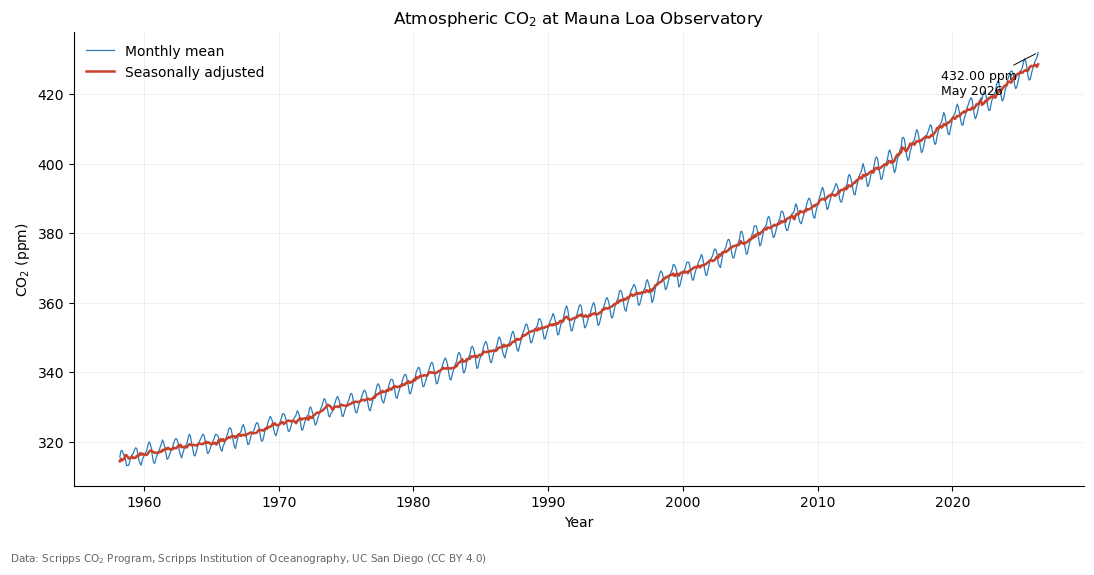

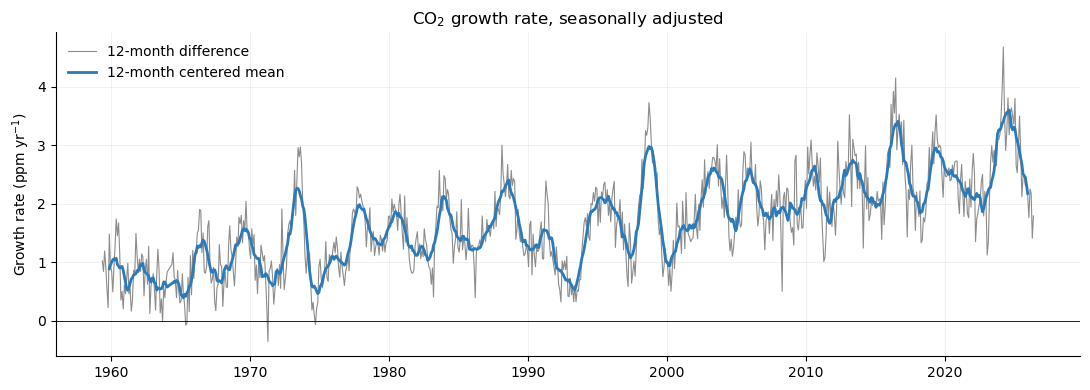

Record spans 1958-03 to 2026-05
Latest monthly mean: 432.00 ppm
Mean growth, last 10 yr: 2.56 ppm/yr


In [19]:
# %% [markdown]
# # Keeling Curve — Scripps monthly in-situ CO2, Mauna Loa
# Source: Scripps CO2 Program (Keeling et al.), CC BY 4.0.
# Landing page: https://scrippsco2.ucsd.edu/data/primary-mauna-loa-co2-record/

# %%
import io
from pathlib import Path
from urllib.request import urlopen

import pandas as pd
import matplotlib.pyplot as plt

URL = "https://keelinglabsites.ucsd.edu/websitedataco2/monthly_in_situ_co2_mlo.csv"
# A script fetched this one, so it goes under data/code-downloaded/ — not beside
# the notebook, and not in data/raw/ which holds files a human downloaded.
CACHE = Path("../data/code-downloaded/co2/monthly_in_situ_co2_mlo.csv")

COLS = [
    "year", "month", "date_excel", "date_frac",
    "co2", "co2_seas_adj", "fit", "fit_seas_adj",
    "co2_filled", "co2_filled_seas_adj", "station",
]


def load_mlo_monthly(url=URL, cache=CACHE):
    """Fetch the Scripps monthly MLO record and return a tidy DataFrame.

    The file carries ~60 lines of quoted header text plus a 3-line column
    header, so we keep only lines that begin with a digit (the data rows).
    Missing values are flagged -99.99 in the raw file.
    """
    cache = Path(cache) if cache else None
    try:
        with urlopen(url, timeout=60) as response:
            text = response.read().decode("utf-8-sig")
        if cache:
            cache.parent.mkdir(parents=True, exist_ok=True)
            cache.write_text(text, encoding="utf-8")
    except Exception as e:
        if cache and cache.exists():
            print(f"Download failed ({e}); falling back to cached copy.")
            text = cache.read_text(encoding="utf-8-sig")
        else:
            raise

    rows = [ln for ln in text.splitlines() if ln.strip()[:1].isdigit()]
    df = pd.read_csv(
        io.StringIO("\n".join(rows)),
        header=None,
        skipinitialspace=True,
        na_values=[-99.99],
    )
    df.columns = COLS[: df.shape[1]]

    # Values are adjusted to 24:00 on the 15th of each month.
    df["date"] = pd.to_datetime(dict(year=df.year, month=df.month, day=15))
    return df.set_index("date")


df = load_mlo_monthly()
df.tail()

# %% [markdown]
# Column 5 (`co2`) is the standard monthly mean on the 2012 SIO manometric
# scale. Column 6 (`co2_seas_adj`) has the quasi-regular seasonal cycle removed
# via a 4-harmonic fit with linear gain. `*_filled` columns patch gaps with the
# spline fit — use those only if you need a continuous series.

# %%
obs = df["co2"].dropna()
adj = df["co2_seas_adj"].dropna()

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(obs.index, obs.values, lw=0.9, color="#2b7bba", label="Monthly mean")
ax.plot(adj.index, adj.values, lw=1.8, color="#c8412b", label="Seasonally adjusted")

ax.set_ylabel("CO$_2$ (ppm)")
ax.set_xlabel("Year")
ax.set_title("Atmospheric CO$_2$ at Mauna Loa Observatory")
ax.legend(frameon=False, loc="upper left")
ax.grid(alpha=0.25, lw=0.5)
ax.spines[["top", "right"]].set_visible(False)

last = obs.iloc[-1]
ax.annotate(
    f"{last:.2f} ppm\n{obs.index[-1]:%b %Y}",
    xy=(obs.index[-1], last),
    xytext=(-70, -30),
    textcoords="offset points",
    fontsize=9,
    arrowprops=dict(arrowstyle="-", lw=0.7),
)

fig.text(
    0.01, -0.03,
    "Data: Scripps CO$_2$ Program, Scripps Institution of Oceanography, UC San Diego (CC BY 4.0)",
    fontsize=7.5, color="0.4",
)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Quick derived quantities

# %%
# Annual means (only years with all 12 monthly values present)
annual = df["co2"].resample("YE").agg(["mean", "count"])
annual = annual[annual["count"] == 12]["mean"]

# Year-over-year growth rate from the seasonally adjusted series
growth = df["co2_seas_adj"].dropna().diff(12)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(growth.index, growth.values, lw=0.8, color="0.55", label="12-month difference")
ax.plot(growth.index, growth.rolling(12, center=True).mean(), lw=2, color="#2b7bba",
        label="12-month centered mean")
ax.axhline(0, color="k", lw=0.6)
ax.set_ylabel("Growth rate (ppm yr$^{-1}$)")
ax.set_title("CO$_2$ growth rate, seasonally adjusted")
ax.legend(frameon=False, loc="upper left")
ax.grid(alpha=0.25, lw=0.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Record spans {obs.index[0]:%Y-%m} to {obs.index[-1]:%Y-%m}")
print(f"Latest monthly mean: {last:.2f} ppm")
recent = growth.loc[growth.index[-1] - pd.DateOffset(years=10):]
print(f"Mean growth, last 10 yr: {recent.mean():.2f} ppm/yr")

Again, walk through the code with the AI's help if you need it – why are these plots different from the one's before?

## Activity 4 — Global electricity generation (Ember)

Activities 1 and 2 handed a file to the chat. Activity 3 handed it a link to a small file. This one cannot be handed over at all: Ember's full yearly release is about **49 MB and 370,000 rows**. It will not fit in a context window, and you cannot scroll through it to check the structure.

That changes the job. You can no longer ask the AI to look at the data. You describe what you want, and you verify the result yourself.

### 4.1 Point your AI tool at the dataset

Ember publishes electricity data — generation, capacity, demand, and power-sector emissions — for every country since 2000.

Example prompt:

```text
Ember publishes global electricity data as a long-format CSV at:
"https://storage.googleapis.com/emb-prod-bkt-publicdata/public-downloads/yearly_full_release_long_format.csv"

It is about 49 MB. Write Python for a Jupyter notebook that downloads it
once, caches it under ../data/code-downloaded/ember/, and plots world electricity
generation by fuel over time. Do not use the requests package, it is not
in my environment. Then tell me how you decided which rows to keep.
```

The last sentence is the one that matters. Section 4.2 explains why.

### Claude Opus 5

In [20]:
from pathlib import Path
from urllib.request import urlretrieve

import pandas as pd

EMBER_URL = (
    "https://storage.googleapis.com/emb-prod-bkt-publicdata/"
    "public-downloads/yearly_full_release_long_format.csv"
)

EMBER_DL = Path("../data/code-downloaded/ember")
EMBER_DL.mkdir(parents=True, exist_ok=True)
ember_csv = EMBER_DL / "yearly_full_release_long_format.csv"

# Acquire once, then work from the local copy.
if ember_csv.exists():
    print(f"Reusing local copy: {ember_csv.stat().st_size / 1e6:.0f} MB")
else:
    print("Downloading ~49 MB, this takes a minute ...")
    urlretrieve(EMBER_URL, ember_csv)

ember = pd.read_csv(ember_csv)
print("rows, columns:", ember.shape)
ember.head()

Reusing local copy: 49 MB
rows, columns: (370784, 18)


,Area,ISO 3 code,Year,Area type,Continent,Ember region,EU,OECD,G20,G7,ASEAN,Category,Subcategory,Variable,Unit,Value,YoY absolute change,YoY % change
0,Afghanistan,AFG,2000,Country or economy,Asia,Asia,0.0,0.0,0.0,0.0,0.0,Capacity,Aggregate fuel,Clean,GW,0.19,NaN,NaN
1,Afghanistan,AFG,2000,Country or economy,Asia,Asia,0.0,0.0,0.0,0.0,0.0,Capacity,Aggregate fuel,Fossil,GW,0.00,NaN,NaN
2,Afghanistan,AFG,2000,Country or economy,Asia,Asia,0.0,0.0,0.0,0.0,0.0,Capacity,Aggregate fuel,Gas and Other Fossil,GW,0.00,NaN,NaN
3,Afghanistan,AFG,2000,Country or economy,Asia,Asia,0.0,0.0,0.0,0.0,0.0,Capacity,Aggregate fuel,"Hydro, Bioenergy and Other Renewables",GW,0.19,NaN,NaN
4,Afghanistan,AFG,2000,Country or economy,Asia,Asia,0.0,0.0,0.0,0.0,0.0,Capacity,Aggregate fuel,Renewables,GW,0.19,NaN,NaN


largest disagreement with Ember's reported total: 0.0000 %


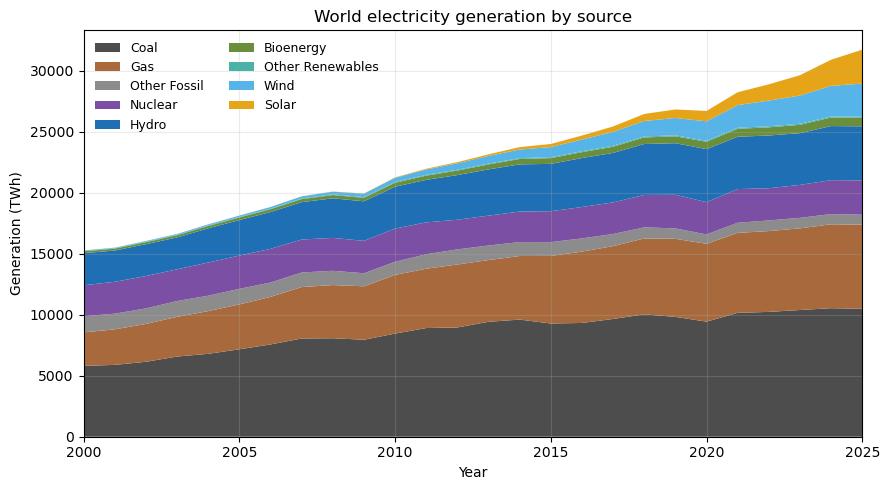

In [21]:
import matplotlib.pyplot as plt

# This one table stacks several units AND three levels of aggregation.
# Every filter below is load-bearing.
world = ember[
    (ember["Area"] == "World")
    & (ember["Category"] == "Electricity generation")
    & (ember["Unit"] == "TWh")
    & (ember["Subcategory"] == "Fuel")
]
by_fuel = world.pivot_table(index="Year", columns="Variable", values="Value", aggfunc="sum")

# Check: the nine fuels must reconcile with the total Ember reports separately.
reported_total = ember[
    (ember["Area"] == "World")
    & (ember["Category"] == "Electricity generation")
    & (ember["Unit"] == "TWh")
    & (ember["Variable"] == "Total Generation")
].set_index("Year")["Value"]

gap = ((by_fuel.sum(axis=1) - reported_total) / reported_total * 100).abs().max()
print(f"largest disagreement with Ember's reported total: {gap:.4f} %")

ORDER = ["Coal", "Gas", "Other Fossil", "Nuclear",
         "Hydro", "Bioenergy", "Other Renewables", "Wind", "Solar"]
COLORS = {
    "Coal": "#4d4d4d", "Gas": "#a86a3d", "Other Fossil": "#8c8c8c",
    "Nuclear": "#7b4fa3", "Hydro": "#1f6fb4", "Bioenergy": "#6b8e3d",
    "Other Renewables": "#4bb3a5", "Wind": "#56b4e9", "Solar": "#e6a419",
}

fig, ax = plt.subplots(figsize=(9, 5))
ax.stackplot(
    by_fuel.index,
    [by_fuel[fuel] for fuel in ORDER],
    labels=ORDER,
    colors=[COLORS[fuel] for fuel in ORDER],
)
ax.set(
    title="World electricity generation by source",
    xlabel="Year",
    ylabel="Generation (TWh)",
    xlim=(by_fuel.index.min(), by_fuel.index.max()),
)
ax.legend(loc="upper left", ncol=2, fontsize=9, frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()

### 4.2 What to check before you believe the figure

Drop any one of those filters and the code still runs. It just answers a different question.

- **`Unit`** — `Electricity generation` is published in both `TWh` and `%`. Without this filter you add percentages to terawatt-hours.
- **`Subcategory`** — the same column holds `Fuel` (Coal, Gas, Solar ...), `Aggregate fuel` (Clean, Fossil), and `Total` (Total Generation). Keep all three and you triple-count every year.
- **`Area`** — areas include countries, regions, and `World`. Group over all of them and every country is counted several times.

The `print` catches all three at once: if the filter is wrong, the disagreement with Ember's own total is large and obvious rather than silent.

- Which of those three did your AI tool handle without being told? **TODO**
- Coal has been roughly flat since 2013 while wind and solar climb steeply. Does this figure show that renewables are *replacing* coal? Look at the height of the whole stack before you answer. **TODO**

### Gemini 3.1